In [1]:
print("hi")

hi


In [ ]:
# import pandas as pd
# import csv

# df = pd.read_csv(
#     "review.tsv",
#     sep="\t",
#     engine="python",
#     quoting=csv.QUOTE_NONE,
#     on_bad_lines="skip"
# )

# print(df.shape)
# print(df.head())

(4366916, 15)
  marketplace  customer_id       review_id  product_id  product_parent  \
0          US     18069663  R3P2HIOQCIN5ZU  B000XB31C0       265024781   
1          US     16251825  R12VVR0WH5Q24V  B00CFYZH5W       259035853   
2          US     20381037   RNCCKB6TV5EEF  B00S8JNN3Q       666066660   
3          US       108364  R2NZXYIVCGB13W  B00XFBPOQG       448483263   
4          US     45449350  R2EQ1TG9IT3OEQ  B00SW64Y9W         7853171   

                                       product_title product_category  \
0  Minnetonka Men's Double Deerskin Softsole Mocc...            Shoes   
1                        Teva Men's Pajaro Flip-Flop            Shoes   
2                   Anne Klein Perfect Pair Wristlet            Shoes   
3          adidas Men's 10K Lifestyle Runner Sneaker            Shoes   
4  OverBling Sneakers for Men Casual Men Shoes Ge...            Shoes   

   star_rating  helpful_votes  total_votes vine verified_purchase  \
0            1              0    

In [7]:
df.shape

(4366916, 15)

In [8]:
df.sample(10)

,marketplace,customer_id,review_id,product_id,product_parent,product_title,product_category,star_rating,helpful_votes,total_votes,vine,verified_purchase,review_headline,review_body,review_date
2420327,US,43081626,RUSB3XZRRK6RQ,B00FBPIADI,518234483,Clear Strappy Sandals with Adjustable Buckle C...,Shoes,5,2,2,N,Y,Great customer service,Very speedy response to my questions. Great cu...,2014-07-07
370034,US,10662658,R296WTKS0KU4LJ,B00QQQCWSA,315688895,Armani Jeans Men's Sandal Flip-Flop,Shoes,5,0,0,N,Y,Five Stars,looks very good ! i love them,2015-07-01
2322551,US,14137379,R1E619FWPKYZBN,B00GKA2XGI,35547074,Disney Sofia The First Flip Flop (Toddler/Big ...,Shoes,5,0,1,N,Y,Gift for my 3 year old princess,I got these shoes for my 3 year old granddaugh...,2014-07-25
411971,US,497780,RSUHGUXMHR0W2,B006QQOXDM,183789319,zeroUV - Vintage Inspired Classic Round Circle...,Shoes,1,0,0,N,Y,"They're reallllly cute, but totally not worth ...","They're reallllly cute, but totally not worth ...",2015-06-23
4029128,US,45823703,R3VRVW7HU5TETU,B004774CJ2,362321042,New Balance Women's WR890 Running Shoe,Shoes,5,3,3,N,Y,Perfect Shoes!,"Love the shoes, they are super light weight, a...",2011-12-29
953599,US,38691143,R1YIA034Q74E9I,B00DI3YYM6,598104568,Eforlife Fashion Korean Style Women Lady Pu Le...,Shoes,1,0,0,N,Y,One Star,NOT WHAT I EXPECTED,2015-03-24
234967,US,6727885,R38EV2W3XDUGTO,B000LLH0V0,323286741,Pleaser Women's Romance-301 Sandal,Shoes,5,0,0,N,Y,Luv Them.,Great but. Fitted my purposes indeed.,2015-07-24
2072270,US,50568092,RCMSJ5ACZ9OY2,B00FL9IXAO,863695537,"""Babo"" Slim Oval Style Celebrity Fashionista P...",Shoes,3,0,0,N,Y,too tight,for reading they are what they are....but tigh...,2014-09-15
241222,US,45637535,R10FNDUX57FH0N,B00OJ9BDHW,580660396,"Thin OPTICS Stick Anywhere, Go Everywhere Read...",Shoes,5,0,0,N,Y,These are a great addition to your phone if yo...,These are a great addition to your phone if yo...,2015-07-23
3705828,US,43936961,RG2QKQSHPI8X6,B006VBPQVK,380507150,KEEN Women's A86 TR Hiking Shoe,Shoes,4,0,1,N,Y,Pointed toe,"First, I love Keen shoes! These shoes are cut...",2013-01-29


In [9]:
df_new = df[['review_id','product_title','star_rating','review_body']]
df_new.sample(5)

,review_id,product_title,star_rating,review_body
1072548,R1105DJ7LES1FH,Clarks Women's Wessex Bria Platform Pump,5,"Love these shoes! They are sexy and oh, so co..."
3838125,R3R4Y3NMQF2LDQ,Steve Madden Women's Carnaby Boot,3,Although these boots are very stylish and extr...
137144,R3VYTYRYLB0SC9,"Caterpillar Men's Second Shift 6"" Plain Soft T...",1,I bought these for my husband and he hates the...
3345003,R32PBNQ3204TGM,Aviator 70's Style Classic Full Mirror Chrome ...,1,they have a bad finish on them and are too lar...
2357692,R334DEEDALI20Q,Skechers Cali Women's Works-Kiss And Run Thong...,3,eeeee


In [11]:
# Create sentiment label based on star rating

def make_label(rating):
    
    if rating >= 4:
        return "positive"
    
    elif rating == 3:
        return "neutral"
    
    else:
        return "negative"

df_new["label"] = df_new["star_rating"].apply(make_label)

# Check output
print(df_new[["star_rating", "label"]].head())

   star_rating     label
0            1  negative
1            5  positive
2            4  positive
3            5  positive
4            3   neutral


In [13]:
df_new.label.value_counts()

label
positive    3487727
negative     475007
neutral      404182
Name: count, dtype: int64

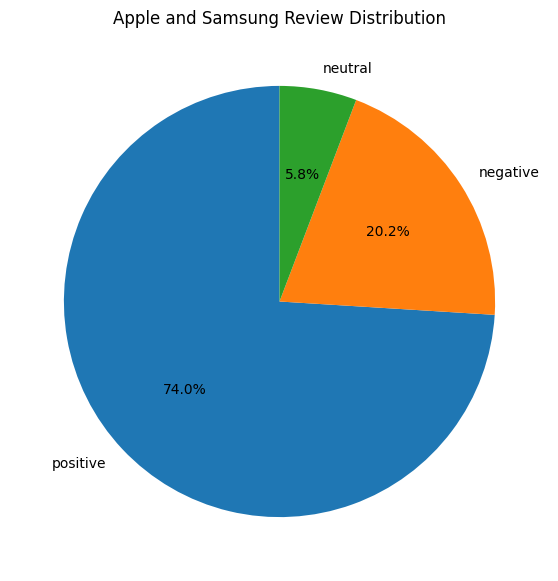

In [12]:
import matplotlib.pyplot as plt

# Data
labels = ['positive', 'negative', 'neutral']
sizes = [109309, 29834, 8545]

# Create pie chart
plt.figure(figsize=(7,7))
plt.pie(
    sizes,
    labels=labels,
    autopct='%1.1f%%',
    startangle=90
)

# Title
plt.title("Apple and Samsung Review Distribution")

# Show chart
plt.show()

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 147688 entries, 0 to 147687
Data columns (total 4 columns):
 #   Column      Non-Null Count   Dtype
---  ------      --------------   -----
 0   Brand Name  147688 non-null  str  
 1   Rating      147688 non-null  int64
 2   Reviews     147649 non-null  str  
 3   label       147688 non-null  str  
dtypes: int64(1), str(3)
memory usage: 4.5 MB


label
good    42056
poor    13192
ok       2939
Name: count, dtype: int64


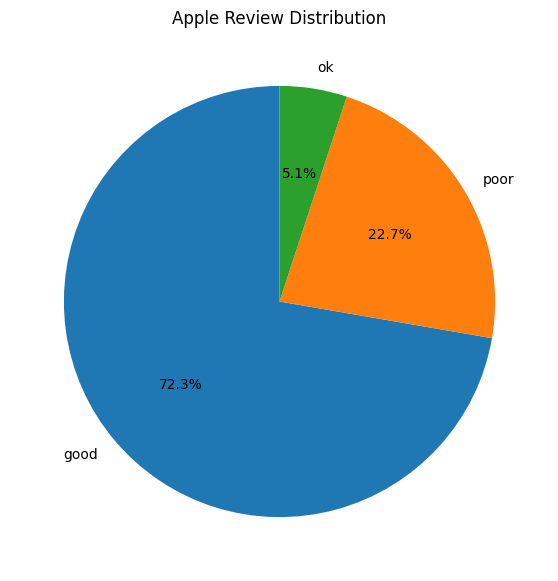

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

# Filter only Apple data
apple_df = df[df['Brand Name'].str.lower() == 'apple']

# Count labels
label_counts = apple_df['label'].value_counts()

# Print counts
print(label_counts)

# Pie Chart
plt.figure(figsize=(7,7))

plt.pie(
    label_counts,
    labels=label_counts.index,
    autopct='%1.1f%%',
    startangle=90
)

plt.title("Apple Review Distribution")

plt.show()

label
good    50428
poor    13745
ok       4547
Name: count, dtype: int64


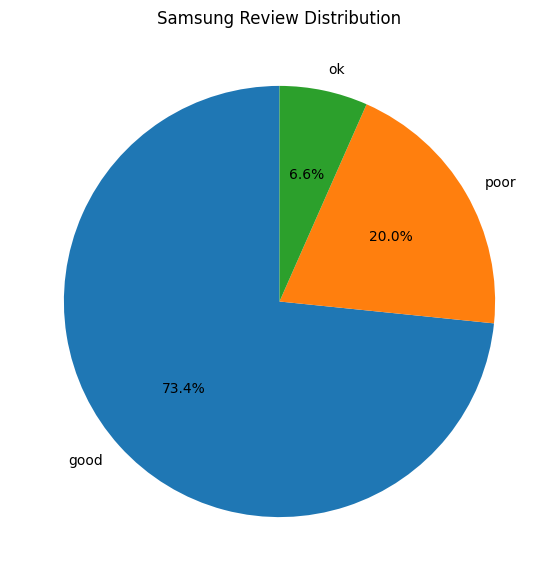

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

# Filter only Samsung data
samsung_df = df[df['Brand Name'].str.lower() == 'samsung']

# Count labels
label_counts = samsung_df['label'].value_counts()

# Print counts
print(label_counts)

# Pie Chart
plt.figure(figsize=(7,7))

plt.pie(
    label_counts,
    labels=label_counts.index,
    autopct='%1.1f%%',
    startangle=90
)

plt.title("Samsung Review Distribution")

plt.show()

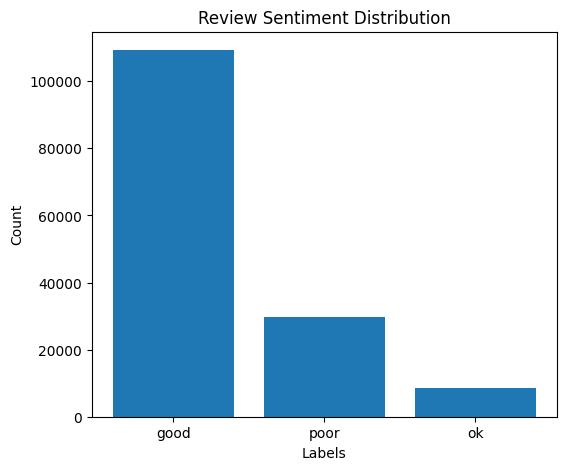

In [9]:
import matplotlib.pyplot as plt

label_counts = df['label'].value_counts()

plt.figure(figsize=(6,5))

plt.bar(label_counts.index, label_counts.values)

plt.xlabel("Labels")
plt.ylabel("Count")
plt.title("Review Sentiment Distribution")

plt.show()

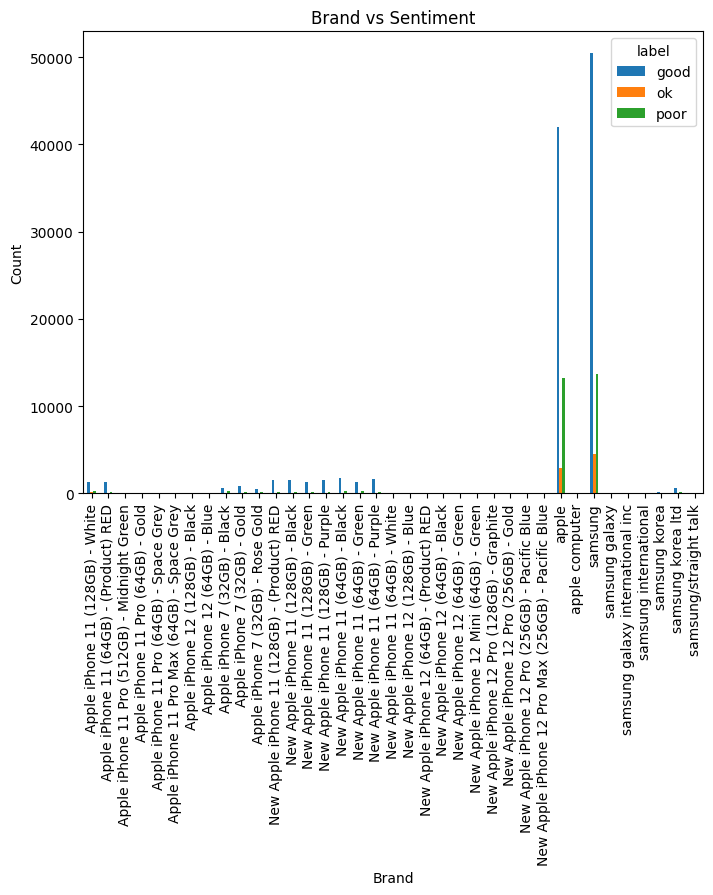

In [10]:
brand_label = pd.crosstab(df['Brand Name'], df['label'])

brand_label.plot(kind='bar', figsize=(8,6))

plt.title("Brand vs Sentiment")
plt.xlabel("Brand")
plt.ylabel("Count")

plt.show()

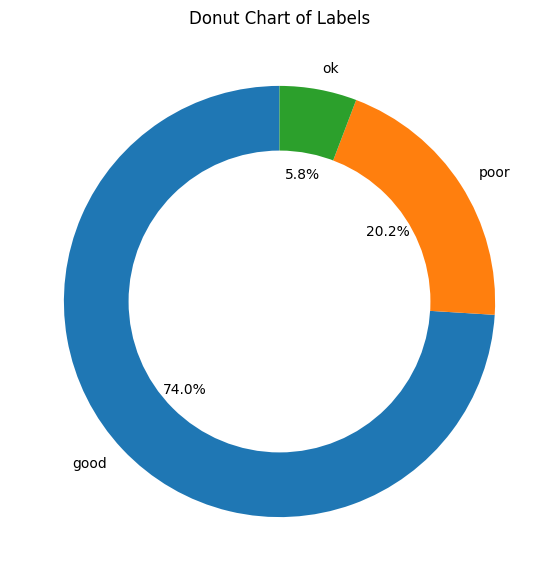

In [11]:
plt.figure(figsize=(7,7))

wedges, texts, autotexts = plt.pie(
    label_counts,
    labels=label_counts.index,
    autopct='%1.1f%%',
    startangle=90
)

centre_circle = plt.Circle((0,0),0.70,fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title("Donut Chart of Labels")

plt.show()

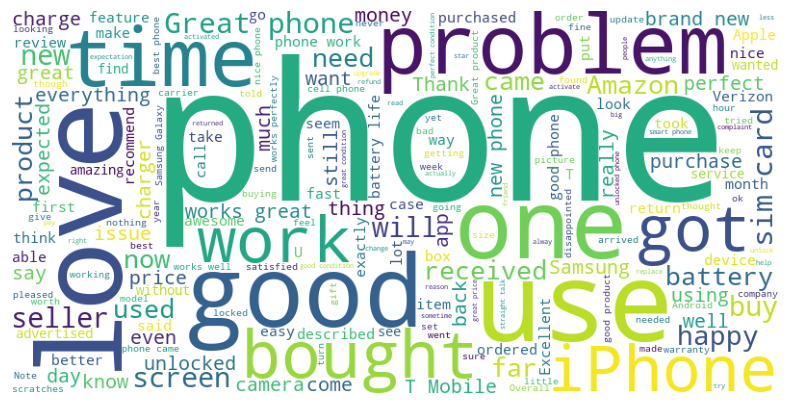

In [12]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

text = " ".join(df['Reviews'].dropna())

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud)
plt.axis("off")

plt.show()